In [23]:
import os
import pandas as pd
import numpy as np
import ee
import geemap
from RadGEEToolbox import GenericCollection, get_palette

In [22]:
service_account = 'localpythonscripts@ut-gee-ugs-bsf-dev.iam.gserviceaccount.com'
credentials = ee.ServiceAccountCredentials(service_account, 'C:\\Users\\mradwin\\ut-gee-ugs-bsf-dev-53dcc5d729e0.json')
ee.Initialize(credentials=credentials)

In [29]:
df = pd.read_csv('C:\\Users\\mradwin\\Downloads\\WaterBudget_Summary\\WB_Summary251119.csv')
df['datetime'] = pd.to_datetime(df['Year'].astype(str))
df = df[df['Year'] >= 2004]
df['value_m3'] = df['Value']*1233.48 #convert from acre-feet to cubic meters
df = df[df['Variable'].isin(['Agriculture GW Pumping', 'Agriculture Surface Diversions', 'Sub-Irrigated Surface Diversions'])].reset_index(drop=True)
df.drop(columns=['Unnamed: 0', 'Value', 'Unit'], inplace=True)

# add summed rows per year
group_cols = ['ModelID', 'Basin', 'Subarea', 'SubareaName', 'State', 'Year', 'datetime']
totals = (
    df.groupby(group_cols, as_index=False)['value_m3']
      .sum()
      .assign(Variable='Total Agriculture Irrigation')
)
df = pd.concat([df, totals], ignore_index=True) #.sort_values(['Year', 'SubareaName']) #.sort_values(['Year', 'Variable']).reset_index(drop=True)
df = df[df['Variable'] == 'Total Agriculture Irrigation'].reset_index(drop=True)
# print(df.head(20))
# df.to_csv('C:\\Users\\mradwin\\Documents\\Utah Soil Water Balance\\WB_Summary_Agriculture_Irrigation_2004_2020.csv', index=False)
df

,ModelID,Basin,Subarea,SubareaName,State,Variable,Year,datetime,value_m3
0,1,Cedar/Beaver,06-02-01,Parowan,Utah,Total Agriculture Irrigation,2004,2004-01-01,5.767717e+07
1,1,Cedar/Beaver,06-02-01,Parowan,Utah,Total Agriculture Irrigation,2005,2005-01-01,6.079015e+07
2,1,Cedar/Beaver,06-02-01,Parowan,Utah,Total Agriculture Irrigation,2006,2006-01-01,6.718280e+07
3,1,Cedar/Beaver,06-02-01,Parowan,Utah,Total Agriculture Irrigation,2007,2007-01-01,5.310409e+07
4,1,Cedar/Beaver,06-02-01,Parowan,Utah,Total Agriculture Irrigation,2008,2008-01-01,6.324469e+07
...,...,...,...,...,...,...,...,...,...
2851,221,Bear River,01-01-07,Brigham City,Utah,Total Agriculture Irrigation,2020,2020-01-01,2.371545e+08
2852,221,Bear River,01-01-07,Brigham City,Utah,Total Agriculture Irrigation,2021,2021-01-01,2.005655e+08
2853,221,Bear River,01-01-07,Brigham City,Utah,Total Agriculture Irrigation,2022,2022-01-01,2.075619e+08
2854,221,Bear River,01-01-07,Brigham City,Utah,Total Agriculture Irrigation,2023,2023-01-01,1.965440e+08


In [2]:
df = pd.read_csv('C:\\Users\\mradwin\\Downloads\\WaterBudget_Summary\\WB_Summary251119.csv')
df['datetime'] = pd.to_datetime(df['Year'].astype(str))
df = df[df['Year'] >= 2004]
df['value_m3'] = df['Value']*1233.48 #convert from acre-feet to cubic meters
df_active = df[df['Variable'].isin(['Agriculture GW Pumping', 'Agriculture Surface Diversions'])].reset_index(drop=True)
df_active.drop(columns=['Unnamed: 0', 'Value', 'Unit'], inplace=True)
df_sub = df[df['Variable'].isin(['Sub-Irrigated Surface Diversions'])].reset_index(drop=True)
df_sub.drop(columns=['Unnamed: 0', 'Value', 'Unit'], inplace=True)



In [3]:
# add summed rows per year
group_cols_active = ['ModelID', 'Basin', 'Subarea', 'SubareaName', 'State', 'Year', 'datetime']
totals_active = (
    df_active.groupby(group_cols_active, as_index=False)['value_m3']
      .sum()
      .assign(Variable='Total Active Agriculture Irrigation')
)
df_active = pd.concat([df_active, totals_active], ignore_index=True) #.sort_values(['Year', 'SubareaName']) #.sort_values(['Year', 'Variable']).reset_index(drop=True)
df_active = df_active[df_active['Variable'] == 'Total Active Agriculture Irrigation'].reset_index(drop=True)
# print(df.head(20))
# df_active.to_csv('C:\\Users\\mradwin\\Documents\\Utah Soil Water Balance\\WB_Summary_Active_Agriculture_Irrigation_2004_2024.csv', index=False)
print(len(df_active['ModelID'].unique()))
df_active

133


,ModelID,Basin,Subarea,SubareaName,State,Variable,Year,datetime,value_m3
0,1,Cedar/Beaver,06-02-01,Parowan,Utah,Total Active Agriculture Irrigation,2004,2004-01-01,5.760353e+07
1,1,Cedar/Beaver,06-02-01,Parowan,Utah,Total Active Agriculture Irrigation,2005,2005-01-01,5.912985e+07
2,1,Cedar/Beaver,06-02-01,Parowan,Utah,Total Active Agriculture Irrigation,2006,2006-01-01,6.524869e+07
3,1,Cedar/Beaver,06-02-01,Parowan,Utah,Total Active Agriculture Irrigation,2007,2007-01-01,5.121732e+07
4,1,Cedar/Beaver,06-02-01,Parowan,Utah,Total Active Agriculture Irrigation,2008,2008-01-01,6.123445e+07
...,...,...,...,...,...,...,...,...,...
2851,221,Bear River,01-01-07,Brigham City,Utah,Total Active Agriculture Irrigation,2020,2020-01-01,2.166121e+08
2852,221,Bear River,01-01-07,Brigham City,Utah,Total Active Agriculture Irrigation,2021,2021-01-01,1.789543e+08
2853,221,Bear River,01-01-07,Brigham City,Utah,Total Active Agriculture Irrigation,2022,2022-01-01,1.901428e+08
2854,221,Bear River,01-01-07,Brigham City,Utah,Total Active Agriculture Irrigation,2023,2023-01-01,1.805704e+08


In [4]:
# add summed rows per year
# group_cols_sub = ['ModelID', 'Basin', 'Subarea', 'SubareaName', 'State', 'Year', 'datetime']
# totals_sub = (
#     df_active.groupby(group_cols_sub, as_index=False)['value_m3']
#       .sum()
#       .assign(Variable='Total Active Agriculture Irrigation')
# )
# df_sub = pd.concat([df_sub, totals_sub], ignore_index=True) #.sort_values(['Year', 'SubareaName']) #.sort_values(['Year', 'Variable']).reset_index(drop=True)
# df_sub = df_sub[df_sub['Variable'] == 'Total Sub-Irrigated Surface Diversions'].reset_index(drop=True)
# print(df.head(20))
# df_sub.to_csv('C:\\Users\\mradwin\\Documents\\Utah Soil Water Balance\\WB_Summary_Sub_Irrigation_2004_2024.csv', index=False)
print(len(df_sub['ModelID'].unique()))
df_sub

133


,ModelID,Basin,Subarea,SubareaName,State,Variable,Year,datetime,value_m3
0,1,Cedar/Beaver,06-02-01,Parowan,Utah,Sub-Irrigated Surface Diversions,2004,2004-01-01,7.363876e+04
1,1,Cedar/Beaver,06-02-01,Parowan,Utah,Sub-Irrigated Surface Diversions,2005,2005-01-01,1.660301e+06
2,1,Cedar/Beaver,06-02-01,Parowan,Utah,Sub-Irrigated Surface Diversions,2006,2006-01-01,1.934109e+06
3,1,Cedar/Beaver,06-02-01,Parowan,Utah,Sub-Irrigated Surface Diversions,2007,2007-01-01,1.886768e+06
4,1,Cedar/Beaver,06-02-01,Parowan,Utah,Sub-Irrigated Surface Diversions,2008,2008-01-01,2.010239e+06
...,...,...,...,...,...,...,...,...,...
2851,221,Bear River,01-01-07,Brigham City,Utah,Sub-Irrigated Surface Diversions,2020,2020-01-01,2.054238e+07
2852,221,Bear River,01-01-07,Brigham City,Utah,Sub-Irrigated Surface Diversions,2021,2021-01-01,2.161120e+07
2853,221,Bear River,01-01-07,Brigham City,Utah,Sub-Irrigated Surface Diversions,2022,2022-01-01,1.741912e+07
2854,221,Bear River,01-01-07,Brigham City,Utah,Sub-Irrigated Surface Diversions,2023,2023-01-01,1.597353e+07


In [33]:
WRLU_crop_groups = ee.FeatureCollection("projects/ut-gee-ugs-bsf-dev/assets/WRLU_4326_LU_Group")
#print feature properties

print(WRLU_crop_groups.first().toDictionary().getInfo())
object_ids = WRLU_crop_groups.aggregate_array('OBJECTID').getInfo()
print(WRLU_crop_groups.aggregate_array('LU_Group').distinct().getInfo())
ActiveIR_features = WRLU_crop_groups.filter(ee.Filter.inList('LU_Group', ['Active IR']))
SubIR_features = WRLU_crop_groups.filter(ee.Filter.inList('LU_Group', ['SubIRR']))

{'Acres': 14.928170209904616, 'Basin': 'Cedar/Beaver', 'Class_Name': 'Shrubland', 'County': 'Iron', 'CropGroup': 'Hay/Turf', 'Descriptio': 'Alfalfa', 'IRR_Method': 'Drip', 'LABEL': 'ALF-D', 'LU_Group': 'Active IR', 'Label_Clas': 'ALF-D Shrub', 'Landuse': 'Agricultural', 'OBJECTID': 2, 'OldLanduse': 'IR', 'SURV_YEAR': '2024', 'Shape__Are': 60412.15832519531, 'Shape__Len': 1007.989195095428, 'State': 'Utah', 'SubArea': 'Cedar'}
['Active IR', 'Dry Ag', 'Idle/Fallow', 'SubIRR', 'RIP', 'Water', 'Urban Grass', 'Urban', 'Wetflats']


In [34]:
object_ids = pd.Series(object_ids).sort_values().reset_index(drop=True)
print('Number of features in Active IR group:', ActiveIR_features.size().getInfo())
print(object_ids)

Number of features in Active IR group: 131114
0              1
1              2
2              3
3              4
4              5
           ...  
283776    332480
283777    332481
283778    332482
283779    332483
283780    332484
Length: 283781, dtype: int64


In [36]:
Map = geemap.Map(center=[39.5, -111.5], zoom=7)
# Map.addLayer(WRLU_crop_groups, {}, 'WRLU Crop Groups')
Map.addLayer(ActiveIR_features.filter(ee.Filter.eq('SubArea', 'Castle Valley')), {}, 'Active IRR')
Map.addLayer(SubIR_features.filter(ee.Filter.eq('SubArea', 'Castle Valley')), {}, 'Sub IRR')
Map

Map(center=[39.5, -111.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [8]:

# 2. Combine them into one dataframe
df_wb = pd.concat([df_active, df_sub])

# 3. Create a dictionary to map the long CSV 'Variable' names to short keys
#    These short keys must match what we will generate in Earth Engine later.
variable_map = {
    'Total Active Agriculture Irrigation': 'Active_Ag',
    'Sub-Irrigated Surface Diversions': 'Sub_Irrigation'
}

# 4. Apply the mapping
df_wb['Type_Short'] = df_wb['Variable'].map(variable_map)

# 5. Clean strings (strip whitespace) to ensure 'Cedar' matches 'Cedar '
# df_wb['SubareaName'] = df_wb['SubareaName'].str.strip() #⚠️
# df_wb['State'] = df_wb['State'].str.strip() #⚠️
df_wb['SubareaName'] = df_wb['SubareaName'].astype(str).str.replace("'", "", regex=False).str.strip()
# df_wb['State'] = df_wb['State'].astype(str).str.strip()

name_corrections = {'Escalante': 'Escalante River', 'Price': 'Price River', 'Upper Santa Clara': 'Santa Clara', 
 'Castle Valley': 'Colorado River/Castle Valley', 'Ferron': 'Ferron Creek', 'Paria': 'Paria River', 
 'San Rafael': 'San Rafael River', 'San Juan': 'San Juan River', 'Cottonwood Creek': 'Little Cottonwood Creek', 
 'Hurricane-Laverkin': 'Laverkin'}

df_wb['SubareaName'] = df_wb['SubareaName'].replace(name_corrections)

# 6. Create the "Static Join Key" (SubArea + State + Type)
#    We use this to link the static polygon areas to the yearly volumes.
# df_wb['static_join_key'] = (
#     df_wb['SubareaName'] + "_" + 
#     df_wb['State'] + "_" + 
#     df_wb['Type_Short']
# )
df_wb['static_join_key'] = (
    df_wb['SubareaName'] + "_" + 
    df_wb['Type_Short']
)

# 7. Create a unique "Yearly Key" (for the final output)
df_wb['yearly_id'] = df_wb['static_join_key'] + "_" + df_wb['Year'].astype(str)

print(f"Loaded {len(df_wb)} rows of water budget data.")
print("Sample Key:", df_wb['static_join_key'].iloc[0])

print(len(df_wb['SubareaName'].unique()))
print(len(df_wb['static_join_key'].unique()))

Loaded 5712 rows of water budget data.
Sample Key: Parowan_Active_Ag
132
264


In [9]:
# -------------------------------------------------------------------------
# PART 2: PREPARE POLYGONS & CALCULATE AREA (Earth Engine)
# -------------------------------------------------------------------------
print("--- Part 2: Calculating Polygon Areas in GEE ---")

# 1. Load the Crop FeatureCollection
#    (Using the asset ID you provided)
crops = ee.FeatureCollection("projects/ut-gee-ugs-bsf-dev/assets/WRLU_4326_LU_Group")

# 2. Filter for only the relevant irrigation types
#    We only want 'Active IR' and 'SubIRR' as defined in your shapefile properties.
relevant_types = ['Active IR', 'SubIRR']
crops_filtered = crops.filter(ee.Filter.inList('LU_Group', relevant_types))

# 3. Define the processing function
def prepare_polygon_properties(feature):
    # Fetch properties using the keys visible in your provided dictionary
    # subarea = ee.String(feature.get('SubArea')).trim() # ⚠️
    subarea = ee.String(feature.get('SubArea')).replace("'", "").trim()
    # state = ee.String(feature.get('State')).trim()

    lu_group = ee.String(feature.get('LU_Group'))
    
    # Map GEE 'LU_Group' to a simplified 'Type_Short' key
    # Logic: If 'Active IR' -> 'Active_Ag', else -> 'Sub_Irrigation'
    # We use ee.Algorithms.If() for server-side conditional logic
    is_active = lu_group.compareTo('Active IR').eq(0)
    type_short = ee.String(ee.Algorithms.If(is_active, 'Active_Ag', 'Sub_Irrigation'))
    
    # Construct the unique Join Key: "SubArea_State_Type"
    # Example: "Cedar_Utah_Active_Ag"
    # join_key = subarea.cat('_').cat(state).cat('_').cat(type_short)
    join_key = subarea.cat('_').cat(type_short)
    
    # Calculate geometry area in Square Meters (more precise than pixel counting)
    area_m2 = feature.geometry().area(1)
    
    # Return feature with new properties required for the join
    return feature.set({
        'static_join_key': join_key, 
        'area_m2': area_m2
    })

# 4. Apply the function
processed_crops = crops_filtered.map(prepare_polygon_properties)

# 5. Aggregate Area by Key
#    Since a SubArea (e.g. Cedar) contains many individual fields, we sum them.
stats = processed_crops.reduceColumns(
    selectors=['static_join_key', 'area_m2'],
    reducer=ee.Reducer.sum().group(
        groupField=0, 
        groupName='static_join_key'
    )
)

# 6. Retrieve results to Python (Client-Side)
print("Fetching area statistics from Earth Engine...")
area_groups = stats.getInfo()['groups']

# Convert to Pandas for the join in Part 3
df_areas = pd.DataFrame(area_groups)
df_areas.columns = ['static_join_key', 'total_area_m2']

print(f"Successfully calculated areas for {len(df_areas)} unique SubArea groups.")
# Preview to verify format
print(df_areas.head(3))

--- Part 2: Calculating Polygon Areas in GEE ---
Fetching area statistics from Earth Engine...
Successfully calculated areas for 257 unique SubArea groups.
             static_join_key  total_area_m2
0  Antelope Island_Active_Ag   2.750440e+04
1        Bear Lake_Active_Ag   2.096986e+08
2   Bear Lake_Sub_Irrigation   9.087934e+07


In [10]:
# -------------------------------------------------------------------------
# PART 3: PROCESS CSVs & CALCULATE DEPTHS (Python/Pandas)
# -------------------------------------------------------------------------
print('length of df_wb before dropna:', len(df_wb))
df_wb = df_wb.dropna(subset=['static_join_key'])
print('length of df_wb after dropna:', len(df_wb))

# --- AGGREGATION STEP (Required for Evanston/Thomas Fork) ---
# We sum the volumes ('value_m3') for any rows that share the same Year and Key.
# This combines the UT and WY portions into one total volume for the subarea.
df_aggregated = df_wb.groupby(['Year', 'static_join_key'])['value_m3'].sum().reset_index()

# 6. JOIN: Merge Volume Data (CSV) with Area Data (GEE)
#    Inner join ensures we only calculate depths for areas that exist in both datasets
# df_final = pd.merge(df_wb, df_areas, on='static_join_key', how='inner')
df_final = pd.merge(df_aggregated, df_areas, on='static_join_key', how='inner')

# 7. Calculate Water Height (Depth)
#    Formula: Depth (m) = Volume (m3) / Area (m2)
df_final['yearly_depth_m'] = df_final['value_m3'] / df_final['total_area_m2']
df_final['yearly_depth_mm'] = df_final['yearly_depth_m'] * 1000

# 8. Calculate Monthly Depth (April - October)
#    We distribute the yearly total over the 7-month irrigation season.
irrigation_months_count = 7
df_final['monthly_depth_m'] = df_final['yearly_depth_m'] / irrigation_months_count
df_final['monthly_depth_mm'] = df_final['yearly_depth_mm'] / irrigation_months_count

# 9. Clean up final dataframe for the Raster Generation loop
# final_data = df_final[['Year', 'static_join_key', 'monthly_depth_m', 'yearly_depth_m', 'SubareaName', 'State']].copy()
final_data = df_final.copy()

print(f"Successfully joined data. {len(final_data)} yearly records ready for rasterization.")
print("Sample of calculated depths:")
print(final_data[['Year', 'static_join_key', 'monthly_depth_mm']].head())
print(final_data.head())
print(final_data['static_join_key'].unique())

length of df_wb before dropna: 5712
length of df_wb after dropna: 5712
Successfully joined data. 5061 yearly records ready for rasterization.
Sample of calculated depths:
   Year            static_join_key  monthly_depth_mm
0  2004        Bear Lake_Active_Ag         64.755359
1  2004   Bear Lake_Sub_Irrigation         37.456156
2  2004  Beaver Dam Wash_Active_Ag         58.738606
3  2004           Beaver_Active_Ag        107.218611
4  2004      Beaver_Sub_Irrigation          0.148956
   Year            static_join_key      value_m3  total_area_m2  \
0  2004        Bear Lake_Active_Ag  9.505376e+07   2.096986e+08   
1  2004   Bear Lake_Sub_Irrigation  2.382793e+07   9.087934e+07   
2  2004  Beaver Dam Wash_Active_Ag  4.320387e+05   1.050754e+06   
3  2004           Beaver_Active_Ag  4.623900e+07   6.160844e+07   
4  2004      Beaver_Sub_Irrigation  1.751542e+03   1.679829e+06   

   yearly_depth_m  yearly_depth_mm  monthly_depth_m  monthly_depth_mm  
0        0.453288       453.287513  

In [11]:
print("--- Step 4: Preparing IDs and Units (Python) ---")

# 1. Extract unique keys from your joined data
#    We ensure they are sorted so the ID assignment is deterministic
unique_keys = sorted(df_final['static_join_key'].unique().tolist())

# 2. Create the Master Lookup Dictionary: { 'String_Key': Integer_ID }
#    Start IDs at 1, because 0 is reserved for "background" (no irrigation)
key_to_id = {key: i + 1 for i, key in enumerate(unique_keys)}

# 3. Map this ID back to your DataFrame
df_final['zone_id'] = df_final['static_join_key'].map(key_to_id)


# 5. Verify the data looks correct
print(f"Assigned IDs for {len(key_to_id)} unique zones.")
print("\nSample of final data ready for GEE:")
print(df_final[['Year', 'static_join_key', 'zone_id', 'monthly_depth_mm']].head())

# Check for NaNs just in case
if df_final['monthly_depth_mm'].isnull().any():
    print("WARNING: Some calculated depths are NaN. Check your CSV volume data.")

--- Step 4: Preparing IDs and Units (Python) ---
Assigned IDs for 241 unique zones.

Sample of final data ready for GEE:
   Year            static_join_key  zone_id  monthly_depth_mm
0  2004        Bear Lake_Active_Ag        1         64.755359
1  2004   Bear Lake_Sub_Irrigation        2         37.456156
2  2004  Beaver Dam Wash_Active_Ag        3         58.738606
3  2004           Beaver_Active_Ag        4        107.218611
4  2004      Beaver_Sub_Irrigation        5          0.148956


In [14]:
# -------------------------------------------------------------------------
# DIAGNOSTIC: DATA INTEGRITY CHECK
# -------------------------------------------------------------------------

# 1. Get the unique keys from both sources
map_keys = set(df_areas['static_join_key'].unique())
csv_keys = set(df_wb['static_join_key'].unique())

# 2. Calculate Mismatches
# Keys in the MAP but missing from the CSV (These polygons will be empty/0 in the final raster)
missing_in_csv = map_keys - csv_keys

# Keys in the CSV but missing from the MAP (We have water data, but no polygons to paint!)
missing_in_map = csv_keys - map_keys

print(f"--- DIAGNOSTIC REPORT ---")
print(f"Total Map Keys: {len(map_keys)}")
print(f"Total CSV Keys: {len(csv_keys)}")
print(f"Successful Matches: {len(map_keys & csv_keys)}")
print("-" * 30)

print(f"\n1. POLYGONS WITHOUT WATER DATA ({len(missing_in_csv)} keys):")
print("(These areas will appear as 0/Background in your rasters)")
print(list(missing_in_csv)[:30]) # Print first 10 examples

print(f"\n2. WATER DATA WITHOUT POLYGONS ({len(missing_in_map)} keys):")
print("(WARNING: This volume data is being discarded because we can't find where to put it)")
print(list(missing_in_map)[:30]) # Print first 10 examples

# 3. Check for specific "Near Misses" (String matching errors)
# Sometimes 'Cedar' in CSV fails to match 'Cedar ' in Map if trimming failed
print(f"\n3. STRING MATCHING CHECK:")
if len(missing_in_map) > 0:
    sample_missing = list(missing_in_map)[0]
    print(f"Checking sample missing key: '{sample_missing}'")
    # Does this exist in the map keys if we ignore case or whitespace?
    # This is a manual logic check you can observe in the output.

--- DIAGNOSTIC REPORT ---
Total Map Keys: 257
Total CSV Keys: 264
Successful Matches: 241
------------------------------

1. POLYGONS WITHOUT WATER DATA (16 keys):
(These areas will appear as 0/Background in your rasters)
['Blacks Fork_Active_Ag', 'Smith Fork_Sub_Irrigation', '_Active_Ag', 'Lake Powell_Active_Ag', 'Indian Creek_Active_Ag', 'Cane Spring_Active_Ag', 'Smith Fork_Active_Ag', 'Antelope Island_Active_Ag', 'Blacks Fork_Sub_Irrigation', 'Colorado River/Dead Horse_Sub_Irrigation', 'Strawberry Reservoir_Sub_Irrigation', 'Snake River_Sub_Irrigation', 'Colorado River/Dead Horse_Active_Ag', 'Cane Spring_Sub_Irrigation', 'Huntington Creek_Active_Ag', 'Snake River_Active_Ag']

2. WATER DATA WITHOUT POLYGONS (23 keys):
(WARNING: This volume data is being discarded because we can't find where to put it)
['Hansel Valley_Sub_Irrigation', 'Scofield_Active_Ag', 'Yellowstone River_Sub_Irrigation', 'Paria River_Sub_Irrigation', 'Range Creek_Active_Ag', 'Lower Beaver River_Sub_Irrigation', 'S

In [ ]:
# Check if the key exists in map_keys
# print(map_keys)
# print(csv_keys)
# if "Colorado River/Cisco_Active_Ag" in map_keys:
#     print("Key found in map_keys!")
# else:
#     print("Key NOT found in map_keys!")

# if "San Juan_Active_Ag" in csv_keys:
#     print("Key found in csv_keys!")
# else:
#     print("Key NOT found in csv_keys!")


['Antelope Island_Active_Ag', 'Bear Lake_Active_Ag', 'Bear Lake_Sub_Irrigation', 'Beaver Dam Wash_Active_Ag', 'Beaver_Active_Ag', 'Beaver_Sub_Irrigation', 'Big Brush Creek_Active_Ag', 'Big Brush Creek_Sub_Irrigation', 'Blacks Fork_Active_Ag', 'Blacks Fork_Sub_Irrigation', 'Blanding_Active_Ag', 'Blanding_Sub_Irrigation', 'Boulder_Active_Ag', 'Boulder_Sub_Irrigation', 'Brigham City_Active_Ag', 'Brigham City_Sub_Irrigation', 'Cache Valley_Active_Ag', 'Cache Valley_Sub_Irrigation', 'Cane Spring_Active_Ag', 'Cane Spring_Sub_Irrigation', 'Canyonlands_Active_Ag', 'Canyonlands_Sub_Irrigation', 'Castle Dale_Active_Ag', 'Castle Dale_Sub_Irrigation', 'Cedar Valley_Active_Ag', 'Cedar_Active_Ag', 'Cedar_Sub_Irrigation', 'Chalk Creek_Active_Ag', 'Chalk Creek_Sub_Irrigation', 'Clear Creek_Active_Ag', 'Cokeville_Active_Ag', 'Cokeville_Sub_Irrigation', 'Colorado River/Castle Valley_Active_Ag', 'Colorado River/Castle Valley_Sub_Irrigation', 'Colorado River/Cisco_Active_Ag', 'Colorado River/Cisco_Sub_Irr

In [15]:
import difflib

# 1. Capture the keys from your previous output (or run this cell after your diagnostic)
#    (Assuming df_areas and df_aggregated are available from the previous step)
map_keys = sorted(list(set(df_areas['static_join_key'].unique())))
csv_keys = sorted(list(set(df_aggregated['static_join_key'].unique())))

# 2. Helper to strip the "_Active_Ag" / "_Sub_Irrigation" suffix
def get_base_name(key):
    return key.replace('_Active_Ag', '').replace('_Sub_Irrigation', '')

map_names = set([get_base_name(k) for k in map_keys])
csv_names = set([get_base_name(k) for k in csv_keys])

# 3. Find names that are in CSV but NOT in Map
missing_names = csv_names - map_names

print(f"Found {len(missing_names)} CSV subareas with no exact Map match.")
print("-" * 60)

proposed_corrections = {}

for csv_name in missing_names:
    # A. Check for "Superstring" matches (e.g. "Colorado River/Castle Valley" contains "Castle Valley")
    #    We look for a map name that is a substring of the CSV name
    substring_matches = [m for m in map_names if m in csv_name and len(m) > 4] # len>4 avoids matching short coincidences
    
    # B. Check for "Substring" matches (e.g. "Laverkin" is inside "Hurricane-Laverkin")
    superstring_matches = [m for m in map_names if csv_name in m]
    
    # C. Check for Close Matches (e.g. "Henrys Fork" vs "Henry's Fork" - though we fixed apostrophes already)
    close_matches = difflib.get_close_matches(csv_name, map_names, n=1, cutoff=0.8)
    
    match = None
    reason = ""
    
    if substring_matches:
        print(substring_matches)
        match = substring_matches[0] # Pick the first/longest
        reason = "Map name is part of CSV name"
    elif superstring_matches:
        print(superstring_matches)
        match = superstring_matches[0]
        reason = "CSV name is part of Map name"
    elif close_matches:
        print(close_matches)
        match = close_matches[0]
        reason = "Fuzzy spelling match"
        
    if match:
        print(f"Mismatch: '{csv_name}'  -->  Likely Match: '{match}' ({reason})")
        proposed_corrections[csv_name] = match

print("-" * 60)
print("Copy this dictionary into your 'name_corrections' map:")
print(proposed_corrections)

Found 2 CSV subareas with no exact Map match.
------------------------------------------------------------
------------------------------------------------------------
Copy this dictionary into your 'name_corrections' map:
{}


In [61]:
####### RASTERIZING SECTION #########
# -------------------------------------------------------------------------
# STEP 5: CREATE BASE ZONE RASTER (Earth Engine)
# -------------------------------------------------------------------------
print("\n--- Step 5: Creating Base Zone Raster in GEE ---")

# 1. Send the Python ID Dictionary to Earth Engine
#    We split it into lists to ensure reliable transfer
gee_keys = list(key_to_id.keys())
gee_values = list(key_to_id.values())
zone_lookup = ee.Dictionary.fromLists(gee_keys, gee_values)
print(zone_lookup.getInfo())
# 2. Add 'zone_id' to the polygons
#    We reuse 'processed_crops' from Part 2 because it already has 'static_join_key'
def add_zone_id(feature):
    key = feature.get('static_join_key') # Use the key we calculated in Part 2
    
    # Lookup the Integer ID. Default to 0 (Background) if not found.
    z_id = zone_lookup.get(key, 0) 
    
    return feature.set('zone_id', z_id)

# 3. Apply and Filter
#    Filter > 0 removes polygons that didn't match any water data (saving processing time)
mapped_crops_final = processed_crops.map(add_zone_id).filter(ee.Filter.gt('zone_id', 0))

# 4. Rasterize ("Paint") the Zones
#    This creates a static map where every pixel value is the Zone ID
base_zone_img = mapped_crops_final.reduceToImage(
    properties=['zone_id'],
    reducer=ee.Reducer.first()
).rename('zone_id').int32() #.reproject(crs='EPSG:32612', scale=30)

print("Base Zone Raster created successfully.")


--- Step 5: Creating Base Zone Raster in GEE ---
{'Bear Lake_Active_Ag': 1, 'Bear Lake_Sub_Irrigation': 2, 'Beaver Dam Wash_Active_Ag': 3, 'Beaver_Active_Ag': 4, 'Beaver_Sub_Irrigation': 5, 'Big Brush Creek_Active_Ag': 6, 'Big Brush Creek_Sub_Irrigation': 7, 'Blanding_Active_Ag': 8, 'Blanding_Sub_Irrigation': 9, 'Boulder_Active_Ag': 10, 'Boulder_Sub_Irrigation': 11, 'Brigham City_Active_Ag': 12, 'Brigham City_Sub_Irrigation': 13, 'Cache Valley_Active_Ag': 14, 'Cache Valley_Sub_Irrigation': 15, 'Canyonlands_Active_Ag': 16, 'Canyonlands_Sub_Irrigation': 17, 'Castle Dale_Active_Ag': 18, 'Castle Dale_Sub_Irrigation': 19, 'Cedar Valley_Active_Ag': 20, 'Cedar_Active_Ag': 21, 'Cedar_Sub_Irrigation': 22, 'Chalk Creek_Active_Ag': 23, 'Chalk Creek_Sub_Irrigation': 24, 'Clear Creek_Active_Ag': 25, 'Cokeville_Active_Ag': 26, 'Cokeville_Sub_Irrigation': 27, 'Colorado River/Castle Valley_Active_Ag': 28, 'Colorado River/Castle Valley_Sub_Irrigation': 29, 'Colorado River/Cisco_Active_Ag': 30, 'Colora

In [62]:
# -------------------------------------------------------------------------
# STEP 6: GENERATE MONTHLY RASTERS
# -------------------------------------------------------------------------
print("\n--- Step 6: Generating Monthly Irrigation Rasters ---")
UT_boundary = ee.FeatureCollection("projects/ut-gee-ugs-bsf-dev/assets/Utah_Regional_Boundary").geometry()
# 1. Setup Configuration
years = range(2004, 2025)
irrigation_months = [4, 5, 6, 7, 8, 9, 10] # Apr-Oct

# 1. Define The Utah Alfalfa Curve (USU Extension based)
monthly_ratios = {
    4: 0.05,  # April: 5%
    5: 0.13,  # May:   13%
    6: 0.20,  # June:  20%
    7: 0.26,  # July:  26% (Peak)
    8: 0.21,  # August: 21%
    9: 0.10,  # Sept:  10%
    10: 0.05  # Oct:   5%
}

# 2. Create a Fast Lookup Dictionary
#    Structure: { (Year, 'static_join_key'): depth_mm }
#    This makes the loop instant because we don't query the DataFrame 3000 times.
data_lookup = df_final.set_index(['Year', 'static_join_key'])['yearly_depth_mm'].to_dict()

# 3. Loop
output_images = []

for year in years:
    for month in range(1, 13):
        
        id_str = f"t_{year}{month:02d}01"  # e.g., "20040401"

        # A. Create Blank Background Image (0 mm)
        monthly_img = ee.Image.constant(0).rename('irrigation_depth_mm').float()
        
        # B. If it is an irrigation month, Remap the Base Raster
        # if month in irrigation_months:
        if month in monthly_ratios:
            ratio = monthly_ratios[month]
            from_ids = []
            to_depths = []
            
            # Iterate through all known zones to find data for THIS year
            for key, z_id in key_to_id.items():
                depth = data_lookup.get((year, key), 0.0)

                monthly_irrigation = depth * ratio
                
                if depth > 0:
                    from_ids.append(z_id)
                    # to_depths.append(depth)
                    to_depths.append(monthly_irrigation)
            
            # Apply .remap()
            if from_ids:
                # Replace ID (e.g., 5) with Depth (e.g., 120.5)
                irrigated_zones = base_zone_img.remap(
                    from_ids,
                    to_depths,
                    defaultValue=0
                ).rename('irrigation_depth_mm').float()
                
                # Update the monthly image
                monthly_img = irrigated_zones
        
        # C. Set Date & Metadata properties
        date_str = f"{year}-{month:02d}-01"
        start_time = ee.Date(date_str).millis()
        end_time = ee.Date(date_str).advance(1, 'month').millis()
        date_obj = ee.Date.fromYMD(year, month, 1) #ee.Date.parse('YYYYMMdd', id_str)
        
        monthly_img = monthly_img.set({
            'system:index': id_str,
            'system:time_start': start_time,
            'system:time_end': end_time,
            'year': year,
            'month': month,
            'units': 'mm',
            'monthly_irrigation_ratio': monthly_ratios.get(month, 0)
        })
        
        # D. Clip to study area (Optional: improves visualization)
        monthly_img = monthly_img.unmask(0).clip(UT_boundary)
        
        output_images.append(monthly_img)

print(f"Generated {len(output_images)} monthly images.")
final_col = ee.ImageCollection(output_images)
final_col_GC = GenericCollection(final_col)
final_col_as_image = final_col.toBands()


--- Step 6: Generating Monthly Irrigation Rasters ---
Generated 252 monthly images.


In [63]:
print(final_col_as_image.bandNames().getInfo())

['t_20040101_irrigation_depth_mm', 't_20040201_irrigation_depth_mm', 't_20040301_irrigation_depth_mm', 't_20040401_irrigation_depth_mm', 't_20040501_irrigation_depth_mm', 't_20040601_irrigation_depth_mm', 't_20040701_irrigation_depth_mm', 't_20040801_irrigation_depth_mm', 't_20040901_irrigation_depth_mm', 't_20041001_irrigation_depth_mm', 't_20041101_irrigation_depth_mm', 't_20041201_irrigation_depth_mm', 't_20050101_irrigation_depth_mm', 't_20050201_irrigation_depth_mm', 't_20050301_irrigation_depth_mm', 't_20050401_irrigation_depth_mm', 't_20050501_irrigation_depth_mm', 't_20050601_irrigation_depth_mm', 't_20050701_irrigation_depth_mm', 't_20050801_irrigation_depth_mm', 't_20050901_irrigation_depth_mm', 't_20051001_irrigation_depth_mm', 't_20051101_irrigation_depth_mm', 't_20051201_irrigation_depth_mm', 't_20060101_irrigation_depth_mm', 't_20060201_irrigation_depth_mm', 't_20060301_irrigation_depth_mm', 't_20060401_irrigation_depth_mm', 't_20060501_irrigation_depth_mm', 't_20060601_i

In [ ]:
task = ee.batch.Export.image.toAsset(
    image=final_col_as_image,
    description='Irrigation_Collection_Export',
    assetId='projects/ut-gee-ugs-bsf-dev/assets/UT_Monthly_Scaled_Irrigation_Depth_Collection_mm_30m',
    region=UT_boundary, 
    scale=30,  
    crs='EPSG:32612', 
    maxPixels=1e13
)

# task.start()

In [33]:
print(final_col_GC.dates)

['2004-01-01', '2004-02-01', '2004-03-01', '2004-04-01', '2004-05-01', '2004-06-01', '2004-07-01', '2004-08-01', '2004-09-01', '2004-10-01', '2004-11-01', '2004-12-01', '2005-01-01', '2005-02-01', '2005-03-01', '2005-04-01', '2005-05-01', '2005-06-01', '2005-07-01', '2005-08-01', '2005-09-01', '2005-10-01', '2005-11-01', '2005-12-01', '2006-01-01', '2006-02-01', '2006-03-01', '2006-04-01', '2006-05-01', '2006-06-01', '2006-07-01', '2006-08-01', '2006-09-01', '2006-10-01', '2006-11-01', '2006-12-01', '2007-01-01', '2007-02-01', '2007-03-01', '2007-04-01', '2007-05-01', '2007-06-01', '2007-07-01', '2007-08-01', '2007-09-01', '2007-10-01', '2007-11-01', '2007-12-01', '2008-01-01', '2008-02-01', '2008-03-01', '2008-04-01', '2008-05-01', '2008-06-01', '2008-07-01', '2008-08-01', '2008-09-01', '2008-10-01', '2008-11-01', '2008-12-01', '2009-01-01', '2009-02-01', '2009-03-01', '2009-04-01', '2009-05-01', '2009-06-01', '2009-07-01', '2009-08-01', '2009-09-01', '2009-10-01', '2009-11-01', '2009

In [59]:
# -------------------------------------------------------------------------
# VERIFICATION 1: Python Math Check
# -------------------------------------------------------------------------
print("--- Verifying Math Logic ---")

# 1. Verify Ratios sum to 1.0
ratio_sum = sum(monthly_ratios.values())
print(f"Sum of monthly ratios: {ratio_sum}")
if abs(ratio_sum - 1.0) > 0.001:
    print("⚠️ WARNING: Your monthly ratios do not sum to 1.0! Check your dictionary.")
else:
    print("✅ Ratios sum to 100%.")

# 2. Sample a random row from your final dataframe
sample = df_final.iloc[0] 
yearly_total = sample['yearly_depth_mm']
join_key = sample['static_join_key']
year = sample['Year']

print(f"\nChecking Sample: {join_key} ({year})")
print(f"Original Yearly Total: {yearly_total:.4f} mm")

# 3. Re-calculate the sum of monthly parts
calculated_sum = 0
print("Monthly Breakdown:")
for month in range(1, 13):
    if month in monthly_ratios:
        ratio = monthly_ratios[month]
        monthly_val = yearly_total * ratio
        print(f"  Month {month}: {monthly_val:.4f} mm ({ratio*100}%)")
        calculated_sum += monthly_val
    else:
        # Months outside the season should be 0
        pass

print(f"Sum of Monthly Parts:  {calculated_sum:.4f} mm")

# 4. Assert Equality
difference = abs(yearly_total - calculated_sum)
if difference < 0.01: # Allow tiny floating point tolerance
    print(f"✅ SUCCESS: Monthly sum matches Yearly total (Diff: {difference:.6f})")
else:
    print(f"❌ FAILURE: Mismatch detected! (Diff: {difference:.6f})")

--- Verifying Math Logic ---
Sum of monthly ratios: 1.0
✅ Ratios sum to 100%.

Checking Sample: Bear Lake_Active_Ag (2004)
Original Yearly Total: 453.2875 mm
Monthly Breakdown:
  Month 4: 22.6644 mm (5.0%)
  Month 5: 58.9274 mm (13.0%)
  Month 6: 90.6575 mm (20.0%)
  Month 7: 117.8548 mm (26.0%)
  Month 8: 95.1904 mm (21.0%)
  Month 9: 45.3288 mm (10.0%)
  Month 10: 22.6644 mm (5.0%)
Sum of Monthly Parts:  453.2875 mm
✅ SUCCESS: Monthly sum matches Yearly total (Diff: 0.000000)


In [29]:
# I NEED TO ADD THIS TO INPUTCOLLECTIONS.PY TO PULL IN THE COLLECTION AS AN IMAGE AND UNPACK IT

def unpack_multiband_to_collection(image):
    # 1. Get all band names (e.g., "20040401_depth", "20040501_depth"...)
    band_names = image.bandNames()
    
    # 2. Map over the list of bands to create a list of Images
    def band_to_image(b_name):
        # Extract the single band
        band = image.select([b_name])
        
        # Parse date from the band name
        # Assumption: Bands are named "YYYYMM01_..." by the export
        # We slice the first 8 characters to get the date string
        date_str = ee.String(b_name).slice(2, 10) 
        date = ee.Date.parse('YYYYMMdd', date_str)
        
        # Rename back to a common name (so all images match)
        # and set the crucial time property
        return band.rename('irrigation_depth_mm').set({
            'system:time_start': date.millis(),
            'year': date.get('year'),
            'month': date.get('month'),
            'Date_Filter': date.format('YYYY-MM-dd')
        })
    
    # 3. Convert list of images to ImageCollection
    images = band_names.map(band_to_image)
    return ee.ImageCollection(images)

# USAGE:
# raw_asset = ee.Image("users/your_user/Utah_Irrigation_Packed")
# irrigation_col = unpack_multiband_to_collection(raw_asset)
# irrigation_col = unpack_multiband_to_collection(final_col_as_image)
# irrigation_col = GenericCollection(irrigation_col)
irrigation_asset = ee.Image("projects/ut-gee-ugs-bsf-dev/assets/UT_Monthly_Scaled_Irrigation_Depth_Collection_mm_30m")
irrigation_col = unpack_multiband_to_collection(irrigation_asset)
irrigation_col = GenericCollection(irrigation_col)

In [30]:
print(irrigation_col.dates)

['2004-01-01', '2004-02-01', '2004-03-01', '2004-04-01', '2004-05-01', '2004-06-01', '2004-07-01', '2004-08-01', '2004-09-01', '2004-10-01', '2004-11-01', '2004-12-01', '2005-01-01', '2005-02-01', '2005-03-01', '2005-04-01', '2005-05-01', '2005-06-01', '2005-07-01', '2005-08-01', '2005-09-01', '2005-10-01', '2005-11-01', '2005-12-01', '2006-01-01', '2006-02-01', '2006-03-01', '2006-04-01', '2006-05-01', '2006-06-01', '2006-07-01', '2006-08-01', '2006-09-01', '2006-10-01', '2006-11-01', '2006-12-01', '2007-01-01', '2007-02-01', '2007-03-01', '2007-04-01', '2007-05-01', '2007-06-01', '2007-07-01', '2007-08-01', '2007-09-01', '2007-10-01', '2007-11-01', '2007-12-01', '2008-01-01', '2008-02-01', '2008-03-01', '2008-04-01', '2008-05-01', '2008-06-01', '2008-07-01', '2008-08-01', '2008-09-01', '2008-10-01', '2008-11-01', '2008-12-01', '2009-01-01', '2009-02-01', '2009-03-01', '2009-04-01', '2009-05-01', '2009-06-01', '2009-07-01', '2009-08-01', '2009-09-01', '2009-10-01', '2009-11-01', '2009

In [ ]:
# final_col_GC.export_to_asset_collection(
#     asset_collection_path = "projects/ut-gee-ugs-bsf-dev/assets/UT_Monthly_Irrigation_Depth_mm_30m",
#     region = UT_boundary,
#     scale = 30,
#     crs='EPSG:32612',
#     description_prefix = 'Irrigation_Export_'
# )

In [37]:
index = -3
Map = geemap.Map(center=[39.5, -111.5], zoom=7)
# Map.addLayer(WRLU_crop_groups, {}, 'WRLU Crop Groups')
# Map.addLayer(base_zone_img, {'min':0, 'max':241}, 'Base Zones')
Map.addLayer(final_col_GC.image_grab(index), {"min":0, "max":150, 'palette': get_palette('inferno')}, 'Monthly Irrigation Depth')
print(final_col_GC.dates[index])
Map

2024-10-01


Map(center=[39.5, -111.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [39]:
irrigation_asset = ee.Image("projects/ut-gee-ugs-bsf-dev/assets/UT_Monthly_Scaled_Irrigation_Depth_Collection_mm_30m")
irrigation_col = unpack_multiband_to_collection(irrigation_asset)
irrigation_col = GenericCollection(irrigation_col)

roi = ee.Geometry.Polygon(
        [[[-112.59292976667221, 39.0604016363254],
          [-112.59292976667221, 38.85536844235735],
          [-112.24548713971909, 38.85536844235735],
          [-112.24548713971909, 39.0604016363254]]])

zonal_stats = irrigation_col.iterate_zonal_stats(roi, band='irrigation_depth_mm', scale=90, reducer_type='mean')

In [54]:
print(df_final)

      Year              static_join_key      value_m3  total_area_m2  \
0     2004          Bear Lake_Active_Ag  9.505376e+07   2.096986e+08   
1     2004     Bear Lake_Sub_Irrigation  2.382793e+07   9.087934e+07   
2     2004    Beaver Dam Wash_Active_Ag  4.320387e+05   1.050754e+06   
3     2004             Beaver_Active_Ag  4.623900e+07   6.160844e+07   
4     2004        Beaver_Sub_Irrigation  1.751542e+03   1.679829e+06   
...    ...                          ...           ...            ...   
5056  2024           Woodland_Active_Ag  5.642468e+06   8.240206e+06   
5057  2024      Woodland_Sub_Irrigation  9.293408e+05   1.803235e+06   
5058  2024  Yellowstone River_Active_Ag  1.591806e+05   1.828667e+05   
5059  2024               Yost_Active_Ag  8.566038e+06   3.065247e+07   
5060  2024          Yost_Sub_Irrigation  5.276827e+04   1.099614e+06   

      yearly_depth_m  yearly_depth_mm  monthly_depth_m  monthly_depth_mm  \
0           0.453288       453.287513         0.064755     

In [60]:
# -------------------------------------------------------------------------
# VERIFICATION 2: GEE Pixel Check
# -------------------------------------------------------------------------
print("\n--- Verifying Earth Engine Output ---")

# 1. Pick a Test Year and Location
test_year = 2010
# Get a key that actually exists in your data
test_key = df_final[df_final['Year'] == test_year]['static_join_key'].iloc[0]
expected_yearly_mm = df_final[(df_final['Year'] == test_year) & 
                              (df_final['static_join_key'] == test_key)]['yearly_depth_mm'].values[0]

print(f"Test Target: {test_key} in {test_year}")
print(f"Expected Yearly Total (from CSV): {expected_yearly_mm:.4f} mm")

# 2. Find the Polygon for this key to get a geometry to sample
#    (We filter the original vector collection)
test_feature = processed_crops.filter(ee.Filter.eq('static_join_key', test_key)).first()
test_geo = test_feature.geometry()

# 3. Sum the Monthly Images for this Year from your generated collection
#    We filter your list-based collection for the specific year
test_col = irrigation_col.collection.filter(ee.Filter.eq('year', test_year))

#    Summing the monthly rasters should reconstruct the yearly total
yearly_sum_img = test_col.sum()

# 4. Sample the value at the polygon
#    We use a reducer to read the pixel value
sampled_val = yearly_sum_img.reduceRegion(
    reducer=ee.Reducer.first(), # All pixels in the zone are same value, so first() is fine
    geometry=test_geo,
    scale=30
).get('irrigation_depth_mm')

# 5. Compare
#    Note: Use .getInfo() to bring the value to Python
gee_val = sampled_val.getInfo()

if gee_val is None:
    print("❌ ERROR: Sampled value is None (Polygon might be masked or missing data)")
else:
    print(f"Actual GEE Raster Sum: {gee_val:.4f} mm")
    
    diff = abs(expected_yearly_mm - gee_val)
    if diff < 0.1: # Small tolerance for float precision
        print(f"✅ MATCH: The GEE rasters sum perfectly to the CSV data!")
    else:
        print(f"❌ MISMATCH: GEE sum {gee_val} != CSV {expected_yearly_mm}")


--- Verifying Earth Engine Output ---
Test Target: Bear Lake_Active_Ag in 2010
Expected Yearly Total (from CSV): 508.4824 mm
Actual GEE Raster Sum: 508.4824 mm
✅ MATCH: The GEE rasters sum perfectly to the CSV data!


          Date  unnamed_geometry_mean
242 2024-03-01               0.000000
243 2024-04-01               4.225160
244 2024-05-01              10.985416
245 2024-06-01              16.900640
246 2024-07-01              21.970832
247 2024-08-01              17.745673
248 2024-09-01               8.450320
249 2024-10-01               4.225160
250 2024-11-01               0.000000
251 2024-12-01               0.000000


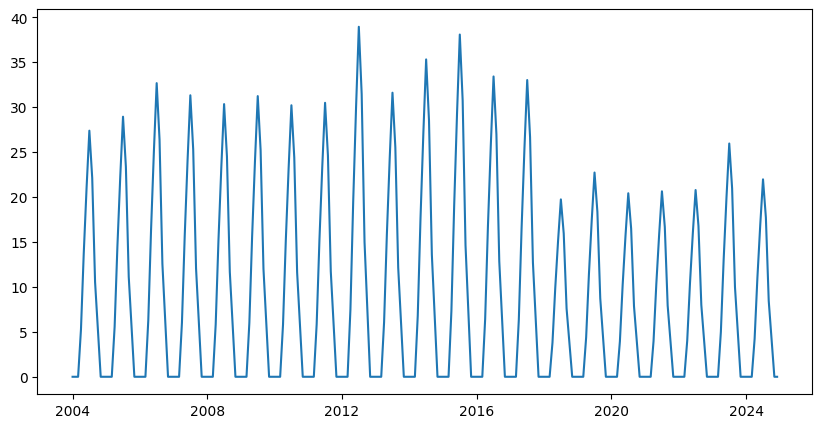

In [58]:
import matplotlib.pyplot as plt
zonal_stats['Date'] = pd.to_datetime(zonal_stats['Date'])
print(zonal_stats.tail(10))
plt.figure(figsize=(10, 5))
plt.plot(zonal_stats['Date'], zonal_stats['unnamed_geometry_mean'])